<a href="https://colab.research.google.com/github/G-Supun/colab-notebooks_Classification/blob/main/classifierPipline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

mount drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install transformers torch scikit-learn pandas openpyxl --quiet

folder mount

In [3]:
import os

BASE = '/content/drive/MyDrive/SMS_Classifier'

PATHS = {
    'raw'        : f'{BASE}/data/raw',
    'processed'  : f'{BASE}/data/processed',
    'best_model' : f'{BASE}/model/best_model',
    'checkpoints': f'{BASE}/model/checkpoints',
    'logs'       : f'{BASE}/logs',
}

for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

print("Drive mounted and folders ready.")

Drive mounted and folders ready.


upload label csv

In [4]:
# ============================================================
# CELL: Upload CSV directly into Drive raw folder
# ============================================================
from google.colab import files

uploaded = files.upload()  # choose csv from your computer

import shutil
for fname in uploaded.keys():
    shutil.move(fname, f"{PATHS['raw']}/{fname}")
    print(f"Moved {fname} to {PATHS['raw']}/")

Saving sms_final_cleaned.csv to sms_final_cleaned.csv
Moved sms_final_cleaned.csv to /content/drive/MyDrive/SMS_Classifier/data/raw/


In [5]:
import pandas as pd

# ============================================================
# CELL: Load sms_final_cleaned.csv from Drive
# ============================================================
RAW_FILE = f"{PATHS['raw']}/sms_final_cleaned.csv"

df = pd.read_csv(RAW_FILE)
print("Shape:", df.shape)
print(df['category'].value_counts())
df.head()

Shape: (110970, 2)
category
transactional    55485
promotional      55485
Name: count, dtype: int64


,message,category
0,TXN ALERT: ₹199 DEBITED FROM A/C ****4679 ON 3...,transactional
1,EXCLUSIVE FOR YOU : VOUCHER ₹100 ON RECHARGE ....,promotional
2,Exclusive for you : flat discount 10 % on food...,promotional
3,'Your Equifax credit information report was ac...,transactional
4,Get 32% off on mobile phones. Limited time offer!,promotional


In [6]:
# ============================================================
# CELL: Basic inspection
# ============================================================
print("Nulls:\n", df.isna().sum())
print("\nDuplicate messages:", df['message'].duplicated().sum())
print("\nMessage length stats (chars):")
print(df['message'].str.len().describe())

Nulls:
 message     0
category    0
dtype: int64

Duplicate messages: 2996

Message length stats (chars):
count    110970.000000
mean        102.018050
std          51.950088
min           6.000000
25%          61.000000
50%          99.000000
75%         140.000000
max         506.000000
Name: message, dtype: float64


In [7]:
# ============================================================
# CELL: Clean text (whitespace, encoding, duplicates, short msgs)
# ============================================================
import re

def clean_text(text):
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    text = text.encode('utf-8', 'ignore').decode('utf-8')
    return text

df['message'] = df['message'].apply(clean_text)

before = len(df)
df = df.drop_duplicates(subset='message').reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows")

df = df[df['message'].str.len() >= 3].reset_index(drop=True)
print("Shape after cleaning:", df.shape)
print(df['category'].value_counts())

Dropped 3081 duplicate rows
Shape after cleaning: (107889, 2)
category
promotional      54559
transactional    53330
Name: count, dtype: int64


In [8]:
# ============================================================
# CELL: Rebalance classes after cleaning
# ============================================================
min_count = df['category'].value_counts().min()

df = (
    df.groupby('category', group_keys=False)
    .sample(n=min_count, random_state=42)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("Balanced shape:", df.shape)
print(df['category'].value_counts())

Balanced shape: (106660, 2)
category
promotional      53330
transactional    53330
Name: count, dtype: int64


In [9]:
# ============================================================
# CELL: Save processed copy
# ============================================================
PROCESSED_FILE = f"{PATHS['processed']}/sms_cleaned_final.csv"
df.to_csv(PROCESSED_FILE, index=False)
print(f"Saved cleaned dataset to {PROCESSED_FILE}")
df.head()

Saved cleaned dataset to /content/drive/MyDrive/SMS_Classifier/data/processed/sms_cleaned_final.csv


,message,category
0,EXCLUSIVE FOR YOU : VOUCHER ₹199 ON RECHARGE ....,promotional
1,Your OTP is 157125. Do not share. ji,transactional
2,TXN ALERT : ₹2499 DEBITED FROM A/C * * * * 765...,transactional
3,Exclusive for you : extra cashback ₹199 on foo...,promotional
4,Your OTP is 724864. Do not share.,transactional


In [10]:
# ============================================================
# CELL: Encode labels
# ============================================================
label2id = {'promotional': 0, 'transactional': 1}
id2label = {v: k for k, v in label2id.items()}

df['label'] = df['category'].map(label2id)

print(df['label'].value_counts())
df.head()

label
0    53330
1    53330
Name: count, dtype: int64


,message,category,label
0,EXCLUSIVE FOR YOU : VOUCHER ₹199 ON RECHARGE ....,promotional,0
1,Your OTP is 157125. Do not share. ji,transactional,1
2,TXN ALERT : ₹2499 DEBITED FROM A/C * * * * 765...,transactional,1
3,Exclusive for you : extra cashback ₹199 on foo...,promotional,0
4,Your OTP is 724864. Do not share.,transactional,1


In [11]:
# ============================================================
# CELL: Train / validation / test split (stratified)
# ============================================================
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42
)

print("Train:", train_df.shape, train_df['label'].value_counts().to_dict())
print("Val:  ", val_df.shape,   val_df['label'].value_counts().to_dict())
print("Test: ", test_df.shape,  test_df['label'].value_counts().to_dict())

Train: (85328, 3) {0: 42664, 1: 42664}
Val:   (10666, 3) {1: 5333, 0: 5333}
Test:  (10666, 3) {0: 5333, 1: 5333}


In [12]:
# ============================================================
# CELL: Save splits to processed folder
# ============================================================
train_df.to_csv(f"{PATHS['processed']}/train.csv", index=False)
val_df.to_csv(f"{PATHS['processed']}/val.csv", index=False)
test_df.to_csv(f"{PATHS['processed']}/test.csv", index=False)

print("Saved train.csv, val.csv, test.csv to", PATHS['processed'])

Saved train.csv, val.csv, test.csv to /content/drive/MyDrive/SMS_Classifier/data/processed


In [13]:
import pandas as pd

train_df = pd.read_csv(f"{PATHS['processed']}/train.csv")
val_df   = pd.read_csv(f"{PATHS['processed']}/val.csv")
test_df  = pd.read_csv(f"{PATHS['processed']}/test.csv")
print(train_df.shape, val_df.shape, test_df.shape)

(85328, 3) (10666, 3) (10666, 3)


Load Model

In [14]:
# ============================================================
# CELL: Load DistilBERT tokenizer
# ============================================================
from transformers import DistilBertTokenizerFast

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Quick sanity check
sample = train_df['message'].iloc[0]
print("Sample text:", sample)
print(tokenizer(sample, truncation=True, max_length=128))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Sample text: TXN ALERT: ₹49 DEBITED FROM A/C ****7375 ON 23-DEC. LIMITED TIME OFFER! FLASH SALE - EXTRA CASHBACK 20. REDEEM AT HTTPS://GO.OOO/7928. AVL BAL ₹999.
{'input_ids': [101, 19067, 2078, 9499, 1024, 1576, 26224, 2139, 16313, 2098, 2013, 1037, 1013, 1039, 1008, 1008, 1008, 1008, 22061, 2629, 2006, 2603, 1011, 11703, 1012, 3132, 2051, 3749, 999, 5956, 5096, 1011, 4469, 5356, 5963, 2322, 1012, 2417, 21564, 2012, 16770, 1024, 1013, 1013, 2175, 1012, 1051, 9541, 1013, 6535, 22407, 1012, 20704, 2140, 28352, 1576, 2683, 2683, 2683, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [15]:
# ============================================================
# CELL: Check token length distribution to pick MAX_LEN
# ============================================================
lengths = train_df['message'].apply(lambda x: len(tokenizer.tokenize(x)))
print(lengths.describe())
print("95th percentile:", lengths.quantile(0.95))
print("99th percentile:", lengths.quantile(0.99))

count    85328.000000
mean        33.018013
std         18.038421
min          2.000000
25%         18.000000
50%         32.000000
75%         45.000000
max        282.000000
Name: message, dtype: float64
95th percentile: 62.0
99th percentile: 78.0


In [16]:
# ============================================================
# CELL: Set max sequence length
# ============================================================
MAX_LEN = 64
print(f"Using MAX_LEN = {MAX_LEN}")

Using MAX_LEN = 64


In [17]:
# ============================================================
# CELL: Build PyTorch Dataset class
# ============================================================
import torch
from torch.utils.data import Dataset

class SMSDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [18]:
# ============================================================
# CELL: Create Dataset objects for train/val/test
# ============================================================
train_dataset = SMSDataset(train_df['message'], train_df['label'], tokenizer)
val_dataset   = SMSDataset(val_df['message'],   val_df['label'],   tokenizer)
test_dataset  = SMSDataset(test_df['message'],  test_df['label'],  tokenizer)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:  ", len(val_dataset))
print("Test dataset size: ", len(test_dataset))

Train dataset size: 85328
Val dataset size:   10666
Test dataset size:  10666


In [19]:
# ============================================================
# CELL: Check GPU availability
# ============================================================
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


add lables to model

In [20]:
from transformers import DistilBertForSequenceClassification

label2id = {'promotional': 0, 'transactional': 1}
id2label = {v: k for k, v in label2id.items()}

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id
)
model.to(device)
print(model.config)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "id2label": {
    "0": "promotional",
    "1": "transactional"
  },
  "initializer_range": 0.02,
  "label2id": {
    "promotional": 0,
    "transactional": 1
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.16.1",
  "vocab_size": 30522
}



In [21]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(len(train_loader), len(val_loader), len(test_loader))

2667 334 334


setup for traning

In [22]:
# ============================================================
# CELL: Training setup (fresh optimizer/scheduler)
# ============================================================
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

EPOCHS = 5
LEARNING_RATE = 1.5e-5  # Slightly lowered for better convergence
WEIGHT_DECAY = 0.01     # Reverted to stable default

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
print(f"Total training steps: {total_steps}")

Total training steps: 13335


Traning cell

In [23]:
# ============================================================
# CELL: Training loop with early stopping (best val loss checkpoint)
# ============================================================
import time
import copy
import torch
from sklearn.metrics import accuracy_score, f1_score

def format_time(seconds):
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

PATIENCE = 2
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
total_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f"\n{'='*60}\nEpoch {epoch+1}/{EPOCHS}\n{'='*60}")

    # ---- Train ----
    model.train()
    train_loss = 0
    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        # Using Hugging Face's optimized internal loss
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ---- Validate ----
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds)
    epoch_time = time.time() - epoch_start

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Train loss: {avg_train_loss:.4f} | Val loss: {avg_val_loss:.4f} | "
          f"Val acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | Time: {format_time(epoch_time)}")

    # ---- Early stopping check ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"  → New best val loss ({best_val_loss:.4f}), saving checkpoint in memory")
    else:
        epochs_no_improve += 1
        print(f"  → No improvement ({epochs_no_improve}/{PATIENCE})")
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

total_time = time.time() - total_start
print(f"\nTotal training time: {format_time(total_time)}")

# Restore best model weights
model.load_state_dict(best_model_state)
print(f"Restored best model (val loss: {best_val_loss:.4f})")


Epoch 1/5
Train loss: 0.1053 | Val loss: 0.0367 | Val acc: 0.9880 | Val F1: 0.9881 | Time: 00:08:52
  → New best val loss (0.0367), saving checkpoint in memory

Epoch 2/5
Train loss: 0.0262 | Val loss: 0.0288 | Val acc: 0.9899 | Val F1: 0.9899 | Time: 00:08:51
  → New best val loss (0.0288), saving checkpoint in memory

Epoch 3/5
Train loss: 0.0151 | Val loss: 0.0437 | Val acc: 0.9896 | Val F1: 0.9896 | Time: 00:08:52
  → No improvement (1/2)

Epoch 4/5
Train loss: 0.0091 | Val loss: 0.0445 | Val acc: 0.9900 | Val F1: 0.9900 | Time: 00:08:53
  → No improvement (2/2)

Early stopping triggered at epoch 4

Total training time: 00:35:31
Restored best model (val loss: 0.0288)


loss graph

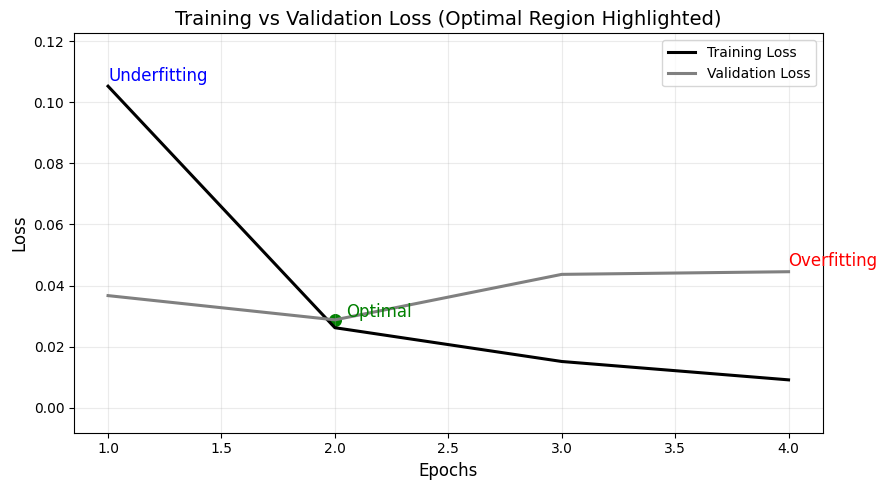

In [24]:
# ============================================================
# CLEAN LOSS GRAPH — Strong Focus on Optimal Region
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

train_loss = history["train_loss"]
val_loss   = history["val_loss"]
epochs     = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(9, 5))

# Clean simple lines
plt.plot(epochs, train_loss, label="Training Loss", color="black", linewidth=2.2)
plt.plot(epochs, val_loss, label="Validation Loss", color="gray", linewidth=2.2)

# Tight scaling around your actual values (0.01–0.04)
all_losses = train_loss + val_loss
min_loss = min(all_losses)
max_loss = max(all_losses)
padding = (max_loss - min_loss) * 0.18

plt.ylim(min_loss - padding, max_loss + padding)

# Labels
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training vs Validation Loss (Optimal Region Highlighted)", fontsize=14)

# Optimal point (lowest validation loss)
best_epoch = val_loss.index(min(val_loss)) + 1
plt.scatter(best_epoch, min(val_loss), color="green", s=70)
plt.text(best_epoch + 0.05, min(val_loss) + padding * 0.05,
         "Optimal", color="green", fontsize=12)

# Underfitting (epoch 1)
plt.text(1, train_loss[0] + padding * 0.1,
         "Underfitting", color="blue", fontsize=12)

# Overfitting (epoch 4)
plt.text(epochs[-1], val_loss[-1] + padding * 0.1,
         "Overfitting", color="red", fontsize=12)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
# ============================================================
# CELL: Save the best model (early-stopped checkpoint)
# ============================================================
model.save_pretrained(PATHS['best_model'])
tokenizer.save_pretrained(PATHS['best_model'])
print(f"Best model saved to {PATHS['best_model']}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to /content/drive/MyDrive/SMS_Classifier/model/best_model


In [26]:
# ============================================================
# CELL: Load saved model for inference (fresh load, standalone use)
# ============================================================
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch

MODEL_PATH = PATHS['best_model']

inference_tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)
inference_model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
inference_model.to(device)
inference_model.eval()

print("Model loaded for inference from:", MODEL_PATH)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded for inference from: /content/drive/MyDrive/SMS_Classifier/model/best_model


In [27]:
# ============================================================
# CELL: Evaluate on held-out test set
# ============================================================
import time
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

model  = inference_model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ─────────────────────────────────────────────────────────
model.eval()
test_preds, test_labels_all, test_probs = [], [], []

start = time.time()
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(outputs.logits, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels_all.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

elapsed = time.time() - start

test_acc = accuracy_score(test_labels_all, test_preds)
test_f1 = f1_score(test_labels_all, test_preds)
test_precision = precision_score(test_labels_all, test_preds)
test_recall = recall_score(test_labels_all, test_preds)

print(f"Test set size: {len(test_labels_all)}")
print(f"Inference time: {elapsed:.2f}s")
print(f"\nTest Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1:        {test_f1:.4f}")

Test set size: 10666
Inference time: 26.66s

Test Accuracy:  0.9893
Test Precision: 0.9871
Test Recall:    0.9916
Test F1:        0.9893


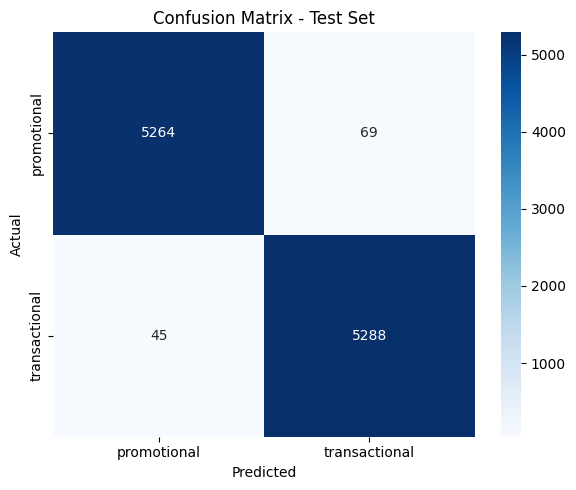


Detailed classification report:
               precision    recall  f1-score   support

  promotional       0.99      0.99      0.99      5333
transactional       0.99      0.99      0.99      5333

     accuracy                           0.99     10666
    macro avg       0.99      0.99      0.99     10666
 weighted avg       0.99      0.99      0.99     10666



In [28]:
# ============================================================
# CELL: Confusion matrix
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels_all, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['promotional', 'transactional'],
    yticklabels=['promotional', 'transactional']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig(f"{PATHS['logs']}/confusion_matrix_test.png", dpi=150)
plt.show()

print("\nDetailed classification report:")
print(classification_report(test_labels_all, test_preds, target_names=['promotional', 'transactional']))

In [29]:
# ============================================================
# CELL 1: Load already-trained DistilBERT model for inference
# ============================================================

import torch

# Use the already-saved model in Google Drive
MODEL_PATH = PATHS['best_model']

# Use GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Load tokenizer
inference_tokenizer = DistilBertTokenizerFast.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

# Load trained model
inference_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_PATH,
    local_files_only=True
)

# Move model to GPU/CPU
inference_model = inference_model.to(device)

# Inference mode
inference_model.eval()

print("=" * 60)
print("ALREADY-TRAINED MODEL READY")
print("=" * 60)
print("Model path :", MODEL_PATH)
print("Device     :", device)

if torch.cuda.is_available():
    print("GPU        :", torch.cuda.get_device_name(0))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

ALREADY-TRAINED MODEL READY
Model path : /content/drive/MyDrive/SMS_Classifier/model/best_model
Device     : cuda
GPU        : Tesla T4


Knowledge Distilization

In [30]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# 1. Load cleaned dataset
PROCESSED_FILE = f"{PATHS['processed']}/sms_cleaned_final.csv"
df = pd.read_csv(PROCESSED_FILE)

category_map = {"promotional": 0, "transactional": 1}
df["label"] = df["category"].str.lower().map(category_map)

# Stratified split: 80% train, 20% validation/test
df_train, df_val = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["label"]
)

train_texts = df_train["message"].astype(str).tolist()
val_texts = df_val["message"].astype(str).tolist()
y_val_ground_truth = df_val["label"].to_numpy()

MAX_LEN = 64
BATCH_SIZE = 256

# 2. Tokenize using DistilBERT tokenizer
print("Tokenizing text sequences...")
train_encodings = inference_tokenizer(
    train_texts, max_length=MAX_LEN, padding="max_length", truncation=True, return_tensors="pt"
)
val_encodings = inference_tokenizer(
    val_texts, max_length=MAX_LEN, padding="max_length", truncation=True, return_tensors="pt"
)

# 3. Extract DistilBERT teacher soft probabilities on GPU
def extract_teacher_probs(encodings, batch_size=BATCH_SIZE):
    dataset = TensorDataset(encodings["input_ids"], encodings["attention_mask"])
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_probs = []

    with torch.no_grad():
        for b_ids, b_mask in loader:
            b_ids, b_mask = b_ids.to(device), b_mask.to(device)
            logits = inference_model(input_ids=b_ids, attention_mask=b_mask).logits
            probs = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs, dtype=np.float32)

print("Extracting DistilBERT teacher soft labels on GPU...")
train_teacher_probs = extract_teacher_probs(train_encodings)
val_teacher_probs = extract_teacher_probs(val_encodings)

# 4. Create PyTorch DataLoaders for Student
train_dataset = TensorDataset(train_encodings["input_ids"], torch.tensor(train_teacher_probs))
val_dataset = TensorDataset(val_encodings["input_ids"], torch.tensor(val_teacher_probs))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"Data prepared: {len(train_dataset):,} train samples, {len(val_dataset):,} val samples.")

Tokenizing text sequences...
Extracting DistilBERT teacher soft labels on GPU...
Data prepared: 85,328 train samples, 21,332 val samples.


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SMSSequenceCNN(nn.Module):
    def __init__(self, vocab_size=30522, embed_dim=64, num_filters=64, filter_sizes=(2, 3, 4), dropout_rate=0.2):
        super(SMSSequenceCNN, self).__init__()

        # 1. Subword Token Embedding Lookup
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. Multi-Kernel 1D Convolution Bank
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in filter_sizes
        ])

        # 3. Dense Classifier Head
        total_conv_out = num_filters * len(filter_sizes)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(total_conv_out, 64)
        self.fc2 = nn.Linear(64, 1)  # Single raw logit output

    def forward(self, input_ids):
        # input_ids: [Batch, Seq_Len]
        x = self.embedding(input_ids)               # [Batch, Seq_Len, Embed_Dim]
        x = x.permute(0, 2, 1)                      # [Batch, Embed_Dim, Seq_Len] for Conv1d

        # Convolve + ReLU + Global Max Pooling
        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(x))                     # [Batch, Num_Filters, L_out]
            pooled = F.adaptive_max_pool1d(c, 1).squeeze(-1) # [Batch, Num_Filters]
            conv_outs.append(pooled)

        feat = torch.cat(conv_outs, dim=1)          # [Batch, Total_Filters]
        feat = self.dropout(feat)

        # Dense classification
        h = F.relu(self.fc1(feat))
        logits = self.fc2(h).squeeze(-1)            # [Batch]
        return logits

# Instantiate and verify parameter footprint
student_cnn = SMSSequenceCNN(vocab_size=inference_tokenizer.vocab_size).to(device)
total_params = sum(p.numel() for p in student_cnn.parameters())
print(f"1D-CNN Student Model Initialized.")
print(f"Total Parameters: {total_params:,} (~{total_params * 4 / (1024 * 1024):.2f} MB footprint)")

1D-CNN Student Model Initialized.
Total Parameters: 2,002,881 (~7.64 MB footprint)


In [32]:
import copy

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(student_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

EPOCHS = 15
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_weights = None

print(f"Beginning 1D-CNN Distillation Training ({EPOCHS} epochs)...")

for epoch in range(1, EPOCHS + 1):
    # --- Training Phase ---
    student_cnn.train()
    total_tr_loss = 0.0
    for b_ids, b_teacher_probs in train_loader:
        b_ids, b_teacher_probs = b_ids.to(device), b_teacher_probs.to(device)

        optimizer.zero_grad()
        logits = student_cnn(b_ids)
        loss = criterion(logits, b_teacher_probs)
        loss.backward()
        optimizer.step()

        total_tr_loss += loss.item() * len(b_ids)

    avg_tr_loss = total_tr_loss / len(train_dataset)
    train_losses.append(avg_tr_loss)

    # --- Validation Phase ---
    student_cnn.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for b_ids, b_teacher_probs in val_loader:
            b_ids, b_teacher_probs = b_ids.to(device), b_teacher_probs.to(device)
            logits = student_cnn(b_ids)
            loss = criterion(logits, b_teacher_probs)
            total_val_loss += loss.item() * len(b_ids)

    avg_val_loss = total_val_loss / len(val_dataset)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(student_cnn.state_dict())

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {avg_tr_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# Restore best checkpoint
student_cnn.load_state_dict(best_model_weights)
torch.save(student_cnn.state_dict(), f"{PATHS['best_model']}/student_cnn.pt")
print(f"\nTraining Complete. Saved optimal checkpoint to: {PATHS['best_model']}/student_cnn.pt")

Beginning 1D-CNN Distillation Training (15 epochs)...
Epoch 01/15 | Train Loss: 0.0842 | Val Loss: 0.0328
Epoch 02/15 | Train Loss: 0.0355 | Val Loss: 0.0286
Epoch 03/15 | Train Loss: 0.0291 | Val Loss: 0.0277
Epoch 04/15 | Train Loss: 0.0250 | Val Loss: 0.0279
Epoch 05/15 | Train Loss: 0.0224 | Val Loss: 0.0250
Epoch 06/15 | Train Loss: 0.0201 | Val Loss: 0.0262
Epoch 07/15 | Train Loss: 0.0190 | Val Loss: 0.0261
Epoch 08/15 | Train Loss: 0.0179 | Val Loss: 0.0235
Epoch 09/15 | Train Loss: 0.0172 | Val Loss: 0.0232
Epoch 10/15 | Train Loss: 0.0160 | Val Loss: 0.0235
Epoch 11/15 | Train Loss: 0.0161 | Val Loss: 0.0239
Epoch 12/15 | Train Loss: 0.0157 | Val Loss: 0.0236
Epoch 13/15 | Train Loss: 0.0147 | Val Loss: 0.0235
Epoch 14/15 | Train Loss: 0.0141 | Val Loss: 0.0230
Epoch 15/15 | Train Loss: 0.0139 | Val Loss: 0.0236

Training Complete. Saved optimal checkpoint to: /content/drive/MyDrive/SMS_Classifier/model/best_model/student_cnn.pt


loss graph

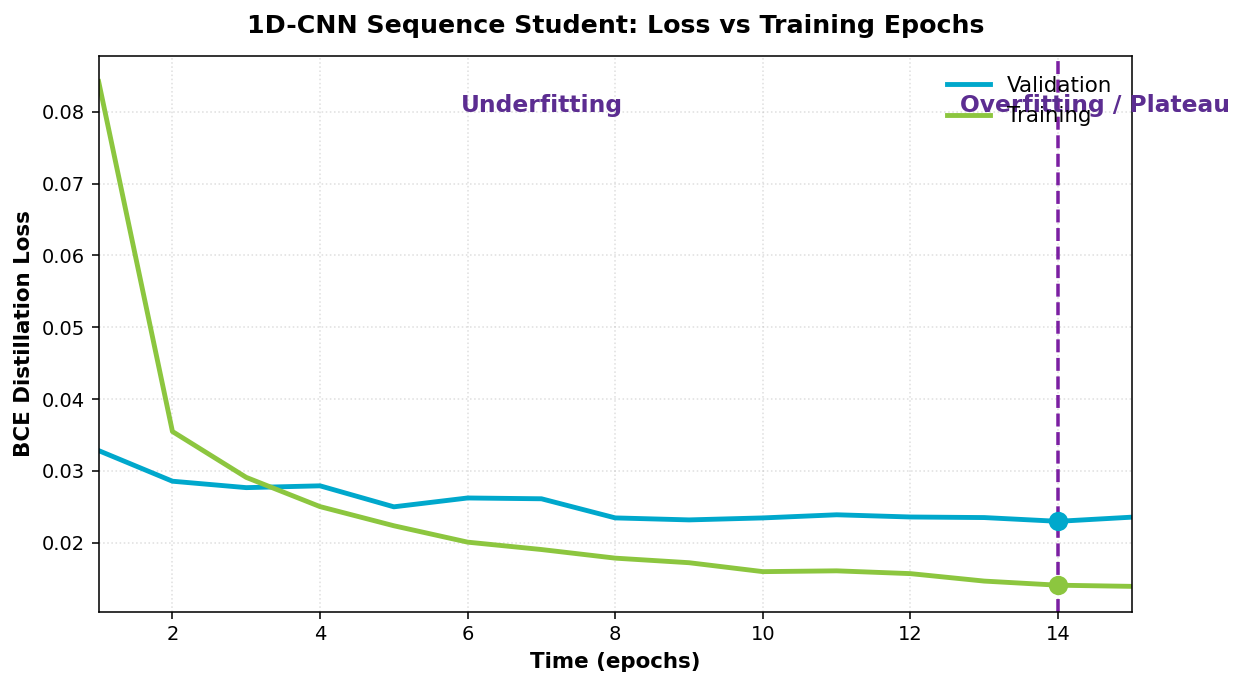

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5), dpi=140)
epochs_range = np.arange(1, len(train_losses) + 1)

# Plot training vs validation lines
plt.plot(epochs_range, val_losses, label="Validation", color="#00a8cc", linewidth=2.5)
plt.plot(epochs_range, train_losses, label="Training", color="#8cc63f", linewidth=2.5)

optimal_epoch = int(np.argmin(val_losses) + 1)
plt.axvline(x=optimal_epoch, color="#7b1fa2", linestyle="--", linewidth=1.8)

plt.scatter([optimal_epoch], [val_losses[optimal_epoch - 1]], color="#00a8cc", s=80, zorder=5)
plt.scatter([optimal_epoch], [train_losses[optimal_epoch - 1]], color="#8cc63f", s=80, zorder=5)

y_text_pos = max(max(train_losses), max(val_losses)) * 0.98
plt.text(optimal_epoch / 2, y_text_pos, "Underfitting",
         ha="center", va="top", fontsize=12, fontweight="bold", color="#5c2d91")
plt.text((optimal_epoch + len(epochs_range)) / 2, y_text_pos, "Overfitting / Plateau",
         ha="center", va="top", fontsize=12, fontweight="bold", color="#5c2d91")

plt.title("1D-CNN Sequence Student: Loss vs Training Epochs", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Time (epochs)", fontsize=11, fontweight="bold")
plt.ylabel("BCE Distillation Loss", fontsize=11, fontweight="bold")
plt.xlim(1, len(epochs_range))
plt.grid(True, linestyle=":", alpha=0.4)
plt.legend(loc="upper right", frameon=False, fontsize=11)
plt.tight_layout()

plt.savefig(f"{PATHS['logs']}/student_cnn_loss_curve.png", dpi=300)
plt.show()

matrics

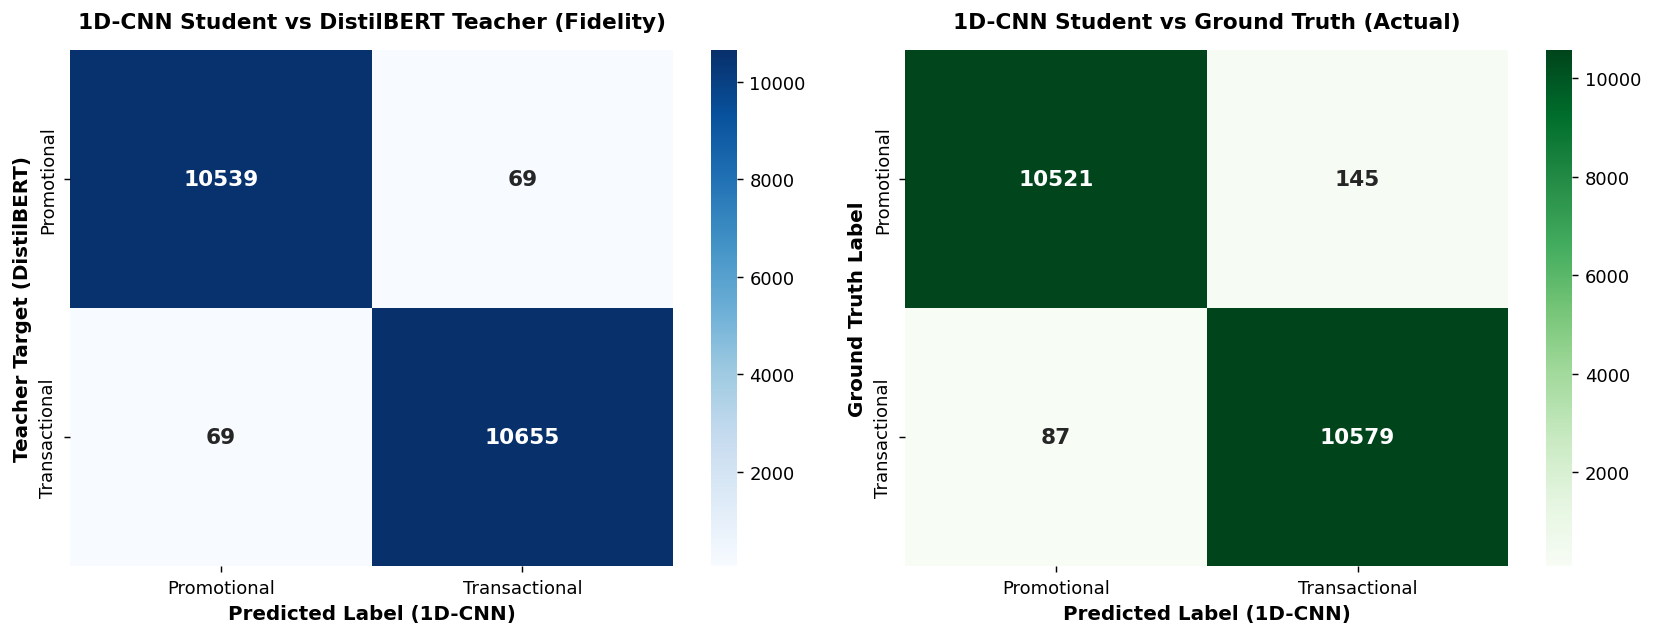


1D-CNN STUDENT ACCURACY REPORT (VS GROUND TRUTH)
               precision    recall  f1-score   support

  promotional     0.9918    0.9864    0.9891     10666
transactional     0.9865    0.9918    0.9892     10666

     accuracy                         0.9891     21332
    macro avg     0.9891    0.9891    0.9891     21332
 weighted avg     0.9891    0.9891    0.9891     21332



In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

student_cnn.eval()
val_preds_list = []

with torch.no_grad():
    for b_ids, _ in val_loader:
        b_ids = b_ids.to(device)
        logits = student_cnn(b_ids)
        preds = (torch.sigmoid(logits) >= 0.5).cpu().numpy().astype(int)
        val_preds_list.extend(preds)

y_val_student_preds = np.array(val_preds_list)
val_teacher_binary = (val_teacher_probs >= 0.5).astype(int)
class_labels = ["Promotional", "Transactional"]

# Generate Confusion Matrices
cm_teacher = confusion_matrix(val_teacher_binary, y_val_student_preds)
cm_ground_truth = confusion_matrix(y_val_ground_truth, y_val_student_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130)

sns.heatmap(cm_teacher, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, ax=axes[0], annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title("1D-CNN Student vs DistilBERT Teacher (Fidelity)", fontsize=12, fontweight="bold", pad=12)
axes[0].set_xlabel("Predicted Label (1D-CNN)", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Teacher Target (DistilBERT)", fontsize=11, fontweight="bold")

sns.heatmap(cm_ground_truth, annot=True, fmt="d", cmap="Greens", xticklabels=class_labels, yticklabels=class_labels, ax=axes[1], annot_kws={"size": 12, "weight": "bold"})
axes[1].set_title("1D-CNN Student vs Ground Truth (Actual)", fontsize=12, fontweight="bold", pad=12)
axes[1].set_xlabel("Predicted Label (1D-CNN)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Ground Truth Label", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{PATHS['logs']}/student_cnn_confusion_matrices.png", dpi=300)
plt.show()

print("\n" + "=" * 60)
print("1D-CNN STUDENT ACCURACY REPORT (VS GROUND TRUTH)")
print("=" * 60)
print(classification_report(y_val_ground_truth, y_val_student_preds, target_names=["promotional", "transactional"], digits=4))

ONNX runtime

In [35]:
!pip install onnxruntime onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 40.6 MB/s eta 0:00:00


In [36]:
!pip install onnx onnxruntime onnxscript -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 12.5 MB/s eta 0:00:00


In [37]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Model Architecture Class Definition
class SMSSequenceCNN(nn.Module):
    def __init__(self, vocab_size=30522, embed_dim=64, num_filters=64, filter_sizes=(2, 3, 4), dropout_rate=0.2):
        super(SMSSequenceCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in filter_sizes
        ])
        total_conv_out = num_filters * len(filter_sizes)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(total_conv_out, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x = x.permute(0, 2, 1)
        conv_outs = []
        for conv in self.convs:
            c = F.relu(conv(x))
            pooled = F.adaptive_max_pool1d(c, 1).squeeze(-1)
            conv_outs.append(pooled)
        feat = torch.cat(conv_outs, dim=1)
        feat = self.dropout(feat)
        h = F.relu(self.fc1(feat))
        logits = self.fc2(h).squeeze(-1)
        return logits

# 3. Instantiate student_cnn
student_cnn = SMSSequenceCNN().to(device)

# 4. Load saved checkpoint weights
CHECKPOINT_PATH = f"{PATHS['best_model']}/student_cnn.pt"
student_cnn.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
student_cnn.eval()

MAX_LEN = 64
print(f"Loaded student_cnn successfully from: {CHECKPOINT_PATH}")

Loaded student_cnn successfully from: /content/drive/MyDrive/SMS_Classifier/model/best_model/student_cnn.pt


In [38]:
import os
import torch

ONNX_EXPORT_PATH = f"{PATHS['best_model']}/student_cnn.onnx"
student_cnn.eval()

# Move dummy input matching MAX_LEN to model device
dummy_input = torch.zeros(1, MAX_LEN, dtype=torch.long).to(device)

# Export with BOTH dynamic batch size (axis 0) and dynamic sequence length (axis 1)
torch.onnx.export(
    student_cnn,
    dummy_input,
    ONNX_EXPORT_PATH,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["input_ids"],
    output_names=["logits"],
    dynamic_axes={
        "input_ids": {0: "batch_size", 1: "sequence_length"},
        "logits": {0: "batch_size"}
    },
    dynamo=False
)

print(f"Exported ONNX model successfully to: {ONNX_EXPORT_PATH}")
print(f"ONNX Model File Size: {os.path.getsize(ONNX_EXPORT_PATH) / (1024 * 1024):.2f} MB")

/tmp/ipykernel_2773/3896557563.py:11: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exported ONNX model successfully to: /content/drive/MyDrive/SMS_Classifier/model/best_model/student_cnn.onnx
ONNX Model File Size: 7.64 MB


Classify

In [42]:
# ============================================================
# CELL: Upload and load new data for classification
# ============================================================
import pandas as pd
import io
from google.colab import files

print("Please upload your new CSV file (must contain 'numbers' and 'message' columns):")
uploaded = files.upload()

# Extract the filename dynamically
filename = list(uploaded.keys())[0]

# Load into a dataframe
new_data_df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\nUploaded '{filename}' successfully!")
print(f"Total rows to process: {len(new_data_df)}")

# Display the first few rows to verify it loaded correctly
new_data_df.head()

Please upload your new CSV file (must contain 'numbers' and 'message' columns):


Saving final_messages_with_mobile.csv to final_messages_with_mobile.csv

Uploaded 'final_messages_with_mobile.csv' successfully!
Total rows to process: 148715


,mobile,message
0,713957917,BK-AMZN: YOUR OTP IS 575718. DO NOT SHARE WITH...
1,717474815,Recharge of Rs 2759 completed on 22-04-2025.
2,729898888,DesiStore : upto 50 % cashback . Use code DEAL...
3,94771954111,Your OTP for verification is 219953. It will e...
4,769229319,Recharge of Rs 1755 completed on 15-03-2025. ji


In [43]:
# ============================================================
# CELL: Run timed batch predictions
# ============================================================
import time
import torch

# Ensure the model is on the GPU and in evaluation mode
inference_model.to(device)
inference_model.eval()

# Configuration
BATCH_SIZE = 32
id2label = {0: 'promotional', 1: 'transactional'}

# Extract messages as a list of strings
texts = new_data_df['message'].astype(str).tolist()
predictions = []

print(f"Starting classification for {len(texts)} messages on {device}...")
start_time = time.time()

# Process in batches
for i in range(0, len(texts), BATCH_SIZE):
    batch_texts = texts[i:i+BATCH_SIZE]

    # Tokenize the current batch
    encodings = inference_tokenizer(
        batch_texts,
        truncation=True,
        padding='max_length',
        max_length=64,
        return_tensors='pt'
    ).to(device)

    # Disable gradient calculation for faster inference
    with torch.no_grad():
        outputs = inference_model(**encodings)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

    predictions.extend(preds)

end_time = time.time()
elapsed_time = end_time - start_time

# Map the numeric predictions (0 or 1) back to text labels
new_data_df['category'] = [id2label[p] for p in predictions]

print("\n" + "="*50)
print(f"✅ Classification Complete!")
print(f"Total time taken:         {elapsed_time:.2f} seconds")
print(f"Average time per message: {(elapsed_time/len(texts))*1000:.2f} milliseconds")
print("="*50)

# Display how many promotional vs transactional messages were found
print("\nPrediction Distribution:")
print(new_data_df['category'].value_counts())

Starting classification for 148715 messages on cuda...

✅ Classification Complete!
Total time taken:         297.20 seconds
Average time per message: 2.00 milliseconds

Prediction Distribution:
category
promotional      75623
transactional    73092
Name: count, dtype: int64


In [44]:
# ============================================================
# CELL: Save classified data to Google Drive
# ============================================================

# Define the output path in your processed folder
output_filename = f"{PATHS['processed']}/classified_new_messages.csv"

# Save the DataFrame to CSV
new_data_df.to_csv(output_filename, index=False)

print(f"Results successfully saved to: {output_filename}\n")

# Preview the final output
new_data_df.head(15)

Results successfully saved to: /content/drive/MyDrive/SMS_Classifier/data/processed/classified_new_messages.csv



,mobile,message,category
0,713957917,BK-AMZN: YOUR OTP IS 575718. DO NOT SHARE WITH...,transactional
1,717474815,Recharge of Rs 2759 completed on 22-04-2025.,transactional
2,729898888,DesiStore : upto 50 % cashback . Use code DEAL...,promotional
3,94771954111,Your OTP for verification is 219953. It will e...,transactional
4,769229319,Recharge of Rs 1755 completed on 15-03-2025. ji,transactional
5,94727559875,Delivery update: AWB 698157564 is out for deli...,transactional
6,94764298251,Delivery update: AWB 182695774 is out for deli...,promotional
7,755562864,LIMITE OFFER! FLAT 20% DISCOUNT ON FOOD ORDER....,promotional
8,775935083,Txn Alert: ₹199 debited from a/c ****4307 on 2...,transactional
9,94702690593,Pre-approved loan of Rs 4114. Apply now.,promotional


In [39]:
import os
import shutil
from google.colab import files

print("Select and upload your CSV file (e.g., messages_with_mobile.csv):")
uploaded = files.upload()

if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    # Move uploaded file directly into the Drive raw directory
    target_path = os.path.join(PATHS['raw'], uploaded_filename)
    shutil.move(uploaded_filename, target_path)

    INPUT_CSV_PATH = target_path
    print("\n" + "=" * 60)
    print(f"File uploaded and saved to: {INPUT_CSV_PATH}")
    print(f"File Size: {os.path.getsize(INPUT_CSV_PATH) / (1024 * 1024):.2f} MB")
    print("=" * 60)
else:
    print("No file uploaded.")

Select and upload your CSV file (e.g., messages_with_mobile.csv):


Saving final_messages_with_mobile.csv to final_messages_with_mobile.csv

File uploaded and saved to: /content/drive/MyDrive/SMS_Classifier/data/raw/final_messages_with_mobile.csv
File Size: 16.31 MB


In [46]:
import os
import time
import psutil
import numpy as np
import pandas as pd
import onnxruntime as ort

# ============================================================
# 1. OPTIMIZED ONNX SESSION (OPTIMAL THREAD ALLOCATION)
# ============================================================
process = psutil.Process(os.getpid())
initial_ram = process.memory_info().rss / (1024 * 1024)

sess_options = ort.SessionOptions()
sess_options.intra_op_num_threads = 2  # Matches Colab CPU vCores to avoid context-switching lock
sess_options.inter_op_num_threads = 1
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

ONNX_MODEL_PATH = f"{PATHS['best_model']}/student_cnn.onnx"
ort_session = ort.InferenceSession(
    ONNX_MODEL_PATH,
    sess_options=sess_options,
    providers=["CPUExecutionProvider"]
)

# Load CSV
df_infer = pd.read_csv(INPUT_CSV_PATH)
texts = df_infer["message"].fillna("").astype(str).tolist()
total_records = len(texts)

# Access direct C++/Rust Tokenizer backend (bypasses Python overhead)
fast_backend_tokenizer = inference_tokenizer.backend_tokenizer
fast_backend_tokenizer.enable_truncation(max_length=64)
fast_backend_tokenizer.enable_padding(length=64, pad_id=0)

# ============================================================
# 2. STREAMING ZERO-COPY INFERENCE LOOP
# ============================================================
cpu_start = time.process_time()
wall_start = time.perf_counter()

BATCH_SIZE = 2048
all_preds = []

for i in range(0, total_records, BATCH_SIZE):
    batch_texts = texts[i : i + BATCH_SIZE]

    # 1. Direct Rust tokenization into contiguous int64 array
    encodings = fast_backend_tokenizer.encode_batch_fast(batch_texts)
    input_ids_chunk = np.array([enc.ids for enc in encodings], dtype=np.int64)

    # 2. ONNX forward pass
    logits_chunk = ort_session.run(["logits"], {"input_ids": input_ids_chunk})[0]

    # 3. Direct sign check (logit >= 0.0 means prob >= 0.5)
    all_preds.extend(logits_chunk >= 0.0)

wall_end = time.perf_counter()
cpu_end = time.process_time()

# ============================================================
# 3. COMPUTE PERFORMANCE, COUNTS & EXPORT
# ============================================================
total_wall_time = wall_end - wall_start
total_cpu_time = cpu_end - cpu_start
throughput = total_records / total_wall_time if total_wall_time > 0 else 0
latency_per_msg = (total_wall_time / total_records) * 1000 if total_records > 0 else 0
final_ram = process.memory_info().rss / (1024 * 1024)
peak_ram_used = max(final_ram - initial_ram, 0.0)

preds_arr = np.array(all_preds, dtype=bool)
df_infer["category"] = np.where(preds_arr, "transactional", "promotional")
df_infer["is_transactional"] = preds_arr

# Calculate class distribution metrics
trans_count = int(preds_arr.sum())
promo_count = int((~preds_arr).sum())
trans_pct = (trans_count / total_records) * 100 if total_records > 0 else 0.0
promo_pct = (promo_count / total_records) * 100 if total_records > 0 else 0.0

OUTPUT_CSV_PATH = f"{PATHS['processed']}/classified_results/messages_with_mobile_cnn_classified.csv"

# Ensure output directory exists
output_dir = f"{PATHS['processed']}/classified_results"
os.makedirs(output_dir, exist_ok=True)

# Save results
df_infer.to_csv(OUTPUT_CSV_PATH, index=False)


# ============================================================
# 4. CONSOLIDATED TELEMETRY REPORT
# ============================================================
print("=" * 60)
print("TRUE ZERO-OVERHEAD 1D-CNN TELEMETRY")
print("=" * 60)
print(f"Messages Processed   : {total_records:,}")
print(f"Total Wall Time      : {total_wall_time:.4f} sec")
print(f"CPU Computation Time : {total_cpu_time:.4f} sec")
print(f"Throughput           : {throughput:,.2f} messages/sec")
print(f"Average Latency      : {latency_per_msg:.4f} ms/message")
print(f"RAM Overhead         : {peak_ram_used:.2f} MB (Total RAM: {final_ram:.2f} MB)")
print("-" * 60)
print("Classification Breakdown:")
print(f"Transactional Count  : {trans_count:,} ({trans_pct:.2f}%)")
print(f"Promotional Count    : {promo_count:,} ({promo_pct:.2f}%)")
print("=" * 60)

TRUE ZERO-OVERHEAD 1D-CNN TELEMETRY
Messages Processed   : 148,715
Total Wall Time      : 37.5058 sec
CPU Computation Time : 58.1710 sec
Throughput           : 3,965.12 messages/sec
Average Latency      : 0.2522 ms/message
RAM Overhead         : 43.76 MB (Total RAM: 3492.84 MB)
------------------------------------------------------------
Classification Breakdown:
Transactional Count  : 75,365 (50.68%)
Promotional Count    : 73,350 (49.32%)
